In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

In [4]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav_history = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv",
    parse_dates=["date"]
)

aum_by_fund_house = pd.read_csv(
    "../data/processed/03_aum_by_fund_house_clean.csv",
    parse_dates=["date"]
)

monthly_sip_inflows = pd.read_csv(
    "../data/processed/04_monthly_sip_inflows_clean.csv",
    parse_dates=["month"]
)

category_inflows = pd.read_csv(
    "../data/processed/05_category_inflows_clean.csv",
    parse_dates=["month"]
)

industry_folio_count = pd.read_csv(
    "../data/processed/06_industry_folio_count_clean.csv",
    parse_dates=["month"]
)

scheme_performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

investor_transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv",
    parse_dates=["transaction_date"]
)

portfolio_holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv",
    parse_dates=["portfolio_date"]
)

benchmark_indices = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv",
    parse_dates=["date"]
)

In [5]:
nav_history = nav_history.sort_values(["amfi_code", "date"])

In [6]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

In [7]:
var_cvar = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()

    var_cvar.append({
        "amfi_code": amfi_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar_report = pd.DataFrame(var_cvar)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [9]:
nav_history = nav_history.sort_values(["amfi_code", "date"])

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

var_cvar_results = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()

    scheme_name = fund_master.loc[
        fund_master["amfi_code"] == amfi_code,
        "scheme_name"
    ].values

    fund_house = fund_master.loc[
        fund_master["amfi_code"] == amfi_code,
        "fund_house"
    ].values

    category = fund_master.loc[
        fund_master["amfi_code"] == amfi_code,
        "category"
    ].values

    var_cvar_results.append({
        "amfi_code": amfi_code,
        "scheme_name": scheme_name[0] if len(scheme_name) > 0 else "",
        "fund_house": fund_house[0] if len(fund_house) > 0 else "",
        "category": category[0] if len(category) > 0 else "",
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar_report = pd.DataFrame(var_cvar_results)

var_cvar_report = var_cvar_report.sort_values(
    by="VaR_95"
)

var_cvar_report.reset_index(
    drop=True,
    inplace=True
)

var_cvar_report.head(10)

,amfi_code,scheme_name,fund_house,category,VaR_95,CVaR_95
0,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,-0.026859,-0.032384
1,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,-0.026188,-0.031667
2,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.026021,-0.032459
3,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,-0.025438,-0.032304
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,-0.024507,-0.030595
5,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,-0.023483,-0.031036
6,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-0.019220,-0.023251
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,-0.019034,-0.023456
8,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,-0.018892,-0.024342
9,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,-0.018480,-0.024260


In [10]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [11]:
var_cvar_report.head(10)

,amfi_code,scheme_name,fund_house,category,VaR_95,CVaR_95
0,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,-0.026859,-0.032384
1,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,-0.026188,-0.031667
2,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.026021,-0.032459
3,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,-0.025438,-0.032304
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,-0.024507,-0.030595
5,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,-0.023483,-0.031036
6,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-0.019220,-0.023251
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,-0.019034,-0.023456
8,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,-0.018892,-0.024342
9,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,-0.018480,-0.024260


In [12]:
var_cvar_report.tail(10)

,amfi_code,scheme_name,fund_house,category,VaR_95,CVaR_95
30,120841,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Equity,-0.013142,-0.016363
31,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,-0.012846,-0.016397
32,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,-0.012613,-0.015490
33,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity,-0.012554,-0.016177
34,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,-0.003938,-0.005014
35,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Debt,-0.003804,-0.004919
36,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,-0.003793,-0.004994
37,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Debt,-0.000285,-0.000411
38,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt,-0.000269,-0.000422
39,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Debt,-0.000222,-0.000373


In [13]:
var_cvar_report.describe()

,amfi_code,VaR_95,CVaR_95
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


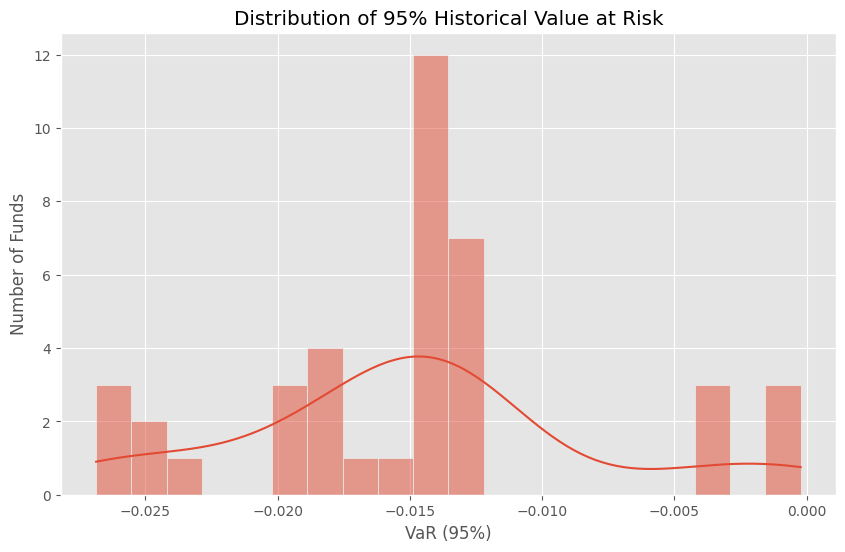

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    var_cvar_report["VaR_95"],
    bins=20,
    kde=True
)

plt.title("Distribution of 95% Historical Value at Risk")
plt.xlabel("VaR (95%)")
plt.ylabel("Number of Funds")

plt.show()

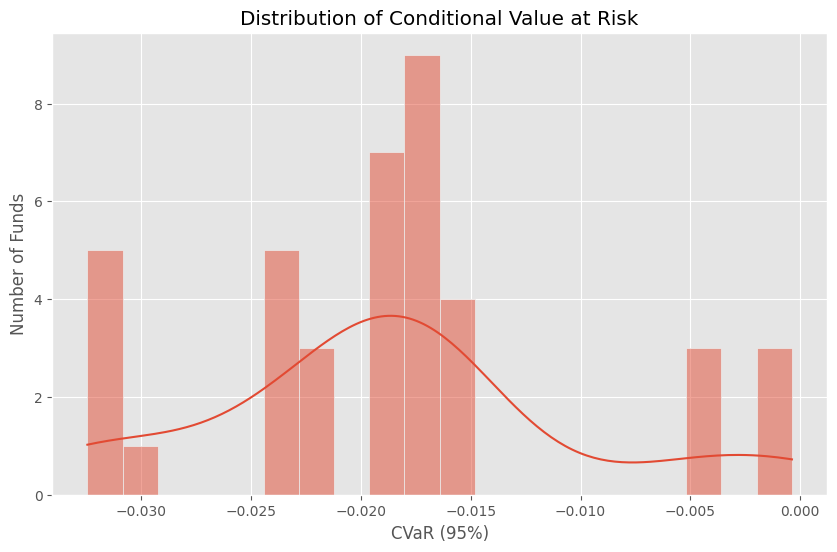

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    var_cvar_report["CVaR_95"],
    bins=20,
    kde=True
)

plt.title("Distribution of Conditional Value at Risk")
plt.xlabel("CVaR (95%)")
plt.ylabel("Number of Funds")

plt.show()

In [16]:
risk_free_rate = 0.065
trading_days = 252

nav_history = nav_history.sort_values(["amfi_code", "date"])

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history["rolling_mean"] = (
    nav_history.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

nav_history["rolling_std"] = (
    nav_history.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

nav_history["rolling_sharpe"] = (
    ((nav_history["rolling_mean"] * trading_days) - risk_free_rate)
    /
    (nav_history["rolling_std"] * np.sqrt(trading_days))
)

nav_history.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


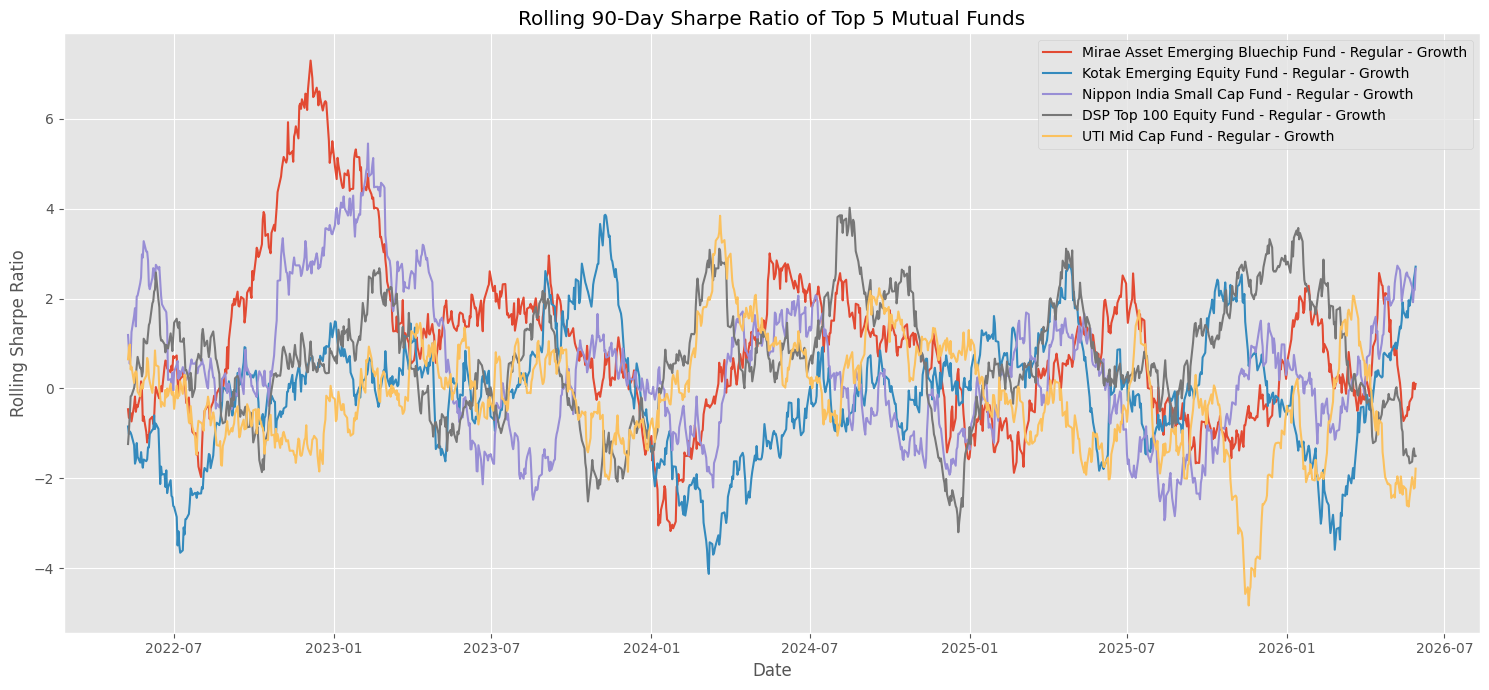

In [17]:
top_funds = (
    scheme_performance
    .sort_values("aum_crore", ascending=False)
    .head(5)
)

top_codes = top_funds["amfi_code"].tolist()

plt.figure(figsize=(15,7))

for code in top_codes:

    temp = nav_history[
        nav_history["amfi_code"] == code
    ]

    scheme_name = (
        top_funds.loc[
            top_funds["amfi_code"] == code,
            "scheme_name"
        ]
        .values[0]
    )

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=scheme_name
    )

plt.title("Rolling 90-Day Sharpe Ratio of Top 5 Mutual Funds")

plt.xlabel("Date")

plt.ylabel("Rolling Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

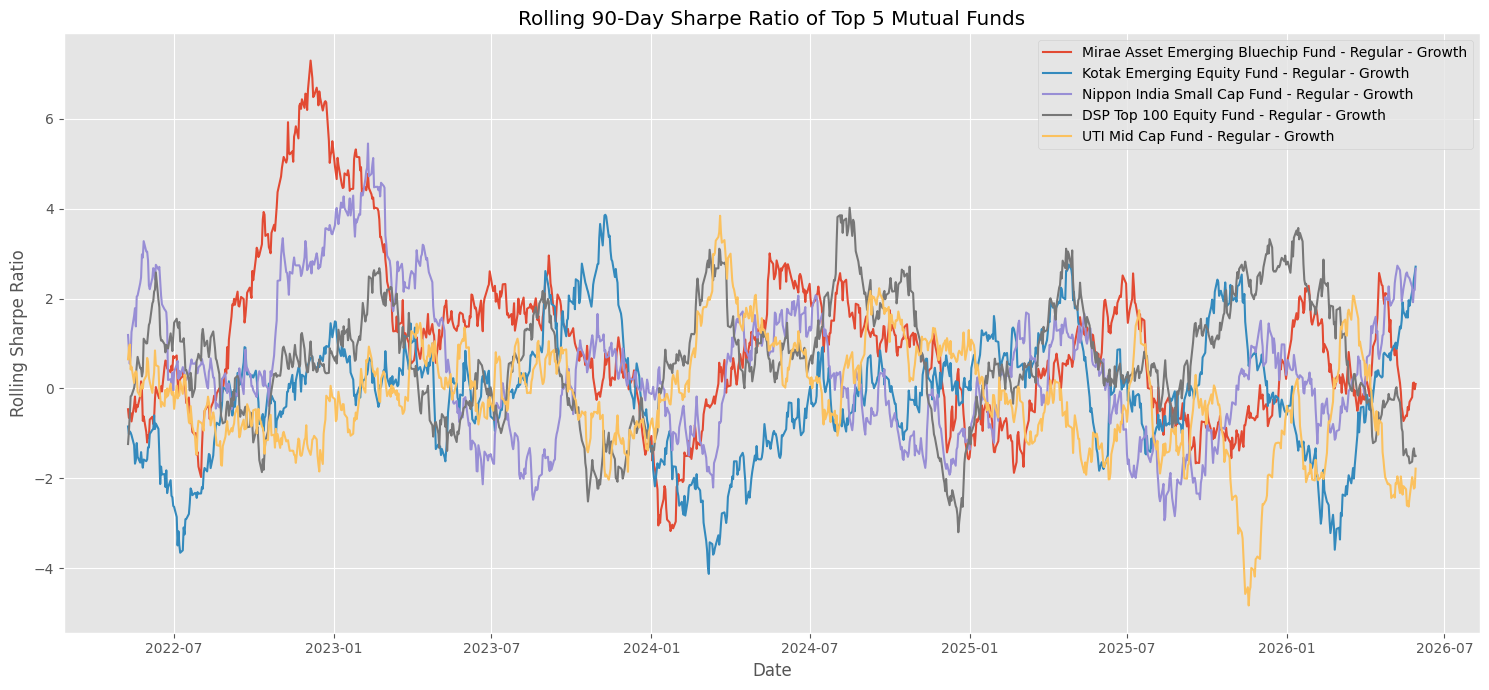

In [18]:
plt.figure(figsize=(15,7))

for code in top_codes:

    temp = nav_history[
        nav_history["amfi_code"] == code
    ]

    scheme_name = (
        top_funds.loc[
            top_funds["amfi_code"] == code,
            "scheme_name"
        ]
        .values[0]
    )

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=scheme_name
    )

plt.title("Rolling 90-Day Sharpe Ratio of Top 5 Mutual Funds")

plt.xlabel("Date")

plt.ylabel("Rolling Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
nav_history[
    [
        "amfi_code",
        "date",
        "daily_return",
        "rolling_sharpe"
    ]
].head(20)

,amfi_code,date,daily_return,rolling_sharpe
0,100016,2022-01-03,NaN,NaN
1,100016,2022-01-04,-0.010306,NaN
2,100016,2022-01-05,0.012865,NaN
3,100016,2022-01-06,-0.011377,NaN
4,100016,2022-01-07,-0.001210,NaN
5,100016,2022-01-10,-0.008639,NaN
6,100016,2022-01-11,0.005562,NaN
7,100016,2022-01-12,-0.002404,NaN
8,100016,2022-01-13,-0.004050,NaN
9,100016,2022-01-14,0.008073,NaN


In [20]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

first_transaction = (
    investor_transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction.rename(
    columns={"transaction_date": "cohort_date"},
    inplace=True
)

first_transaction["cohort_year"] = (
    first_transaction["cohort_date"].dt.year
)

first_transaction.head()

,investor_id,cohort_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [21]:
investor_transactions = investor_transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

investor_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [22]:
investor_transactions = investor_transactions.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

investor_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,Axis Midcap Fund - Regular - Growth


In [23]:
avg_sip = (
    investor_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
)

avg_sip.rename(
    columns={"amount_inr": "average_sip_amount"},
    inplace=True
)

avg_sip

,cohort_year,average_sip_amount
0,2024,107422.541832
1,2025,109158.577061


In [24]:
total_investment = (
    investor_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
)

total_investment.rename(
    columns={"amount_inr": "total_investment"},
    inplace=True
)

total_investment

,cohort_year,total_investment
0,2024,3491125187
1,2025,30455243


In [25]:
top_fund = (
    investor_transactions
    .groupby(
        ["cohort_year", "scheme_name"]
    )
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund = top_fund[
    ["cohort_year", "scheme_name"]
]

top_fund.rename(
    columns={
        "scheme_name": "top_fund"
    },
    inplace=True
)

top_fund

,cohort_year,top_fund
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...
57,2025,ICICI Pru Liquid Fund - Regular - Growth


In [26]:
cohort_report = (
    avg_sip
    .merge(
        total_investment,
        on="cohort_year"
    )
    .merge(
        top_fund,
        on="cohort_year"
    )
)

cohort_report

,cohort_year,average_sip_amount,total_investment,top_fund
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,ICICI Pru Liquid Fund - Regular - Growth


In [27]:
cohort_report.to_csv(
    "../reports/investor_cohort_report.csv",
    index=False
)

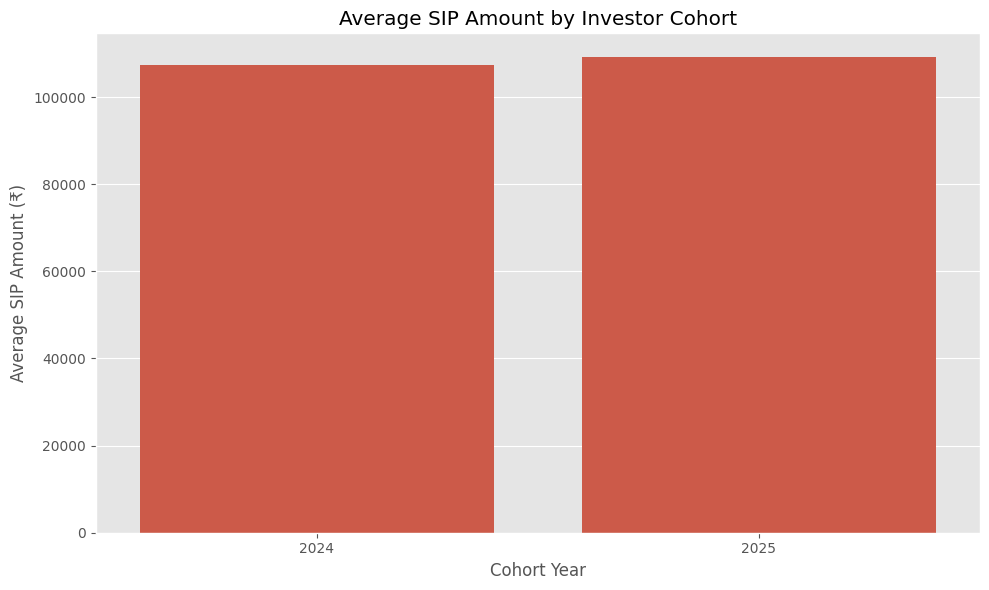

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=cohort_report,
    x="cohort_year",
    y="average_sip_amount"
)

plt.title("Average SIP Amount by Investor Cohort")

plt.xlabel("Cohort Year")

plt.ylabel("Average SIP Amount (₹)")

plt.tight_layout()

plt.show()

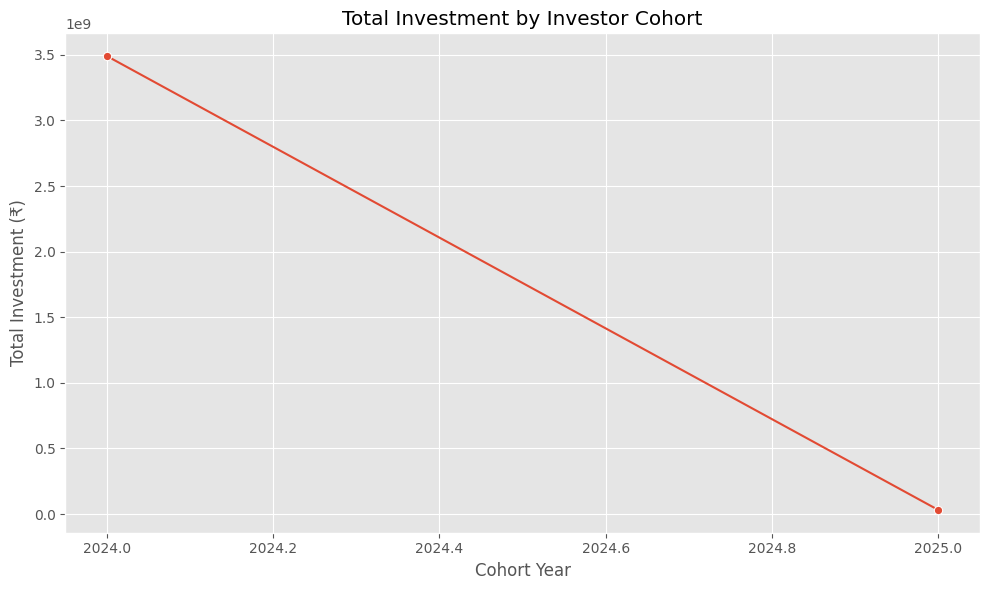

In [29]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=cohort_report,
    x="cohort_year",
    y="total_investment",
    marker="o"
)

plt.title("Total Investment by Investor Cohort")

plt.xlabel("Cohort Year")

plt.ylabel("Total Investment (₹)")

plt.tight_layout()

plt.show()

In [30]:
investor_transactions = investor_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

In [31]:
sip_transactions = investor_transactions[
    investor_transactions["transaction_type"].str.lower() == "sip"
].copy()

In [32]:
sip_transactions["previous_transaction"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .shift(1)
)

sip_transactions["gap_days"] = (
    sip_transactions["transaction_date"]
    - sip_transactions["previous_transaction"]
).dt.days

In [33]:
sip_count = (
    sip_transactions
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_count[
    sip_count["sip_count"] >= 2
]["investor_id"]

sip_transactions = sip_transactions[
    sip_transactions["investor_id"].isin(eligible_investors)
]

In [34]:
continuity_report = (
    sip_transactions
    .groupby("investor_id")
    .agg(
        average_gap_days=("gap_days", "mean"),
        total_sips=("transaction_date", "count"),
        total_investment=("amount_inr", "sum")
    )
    .reset_index()
)

In [35]:
continuity_report["status"] = np.where(
    continuity_report["average_gap_days"] > 35,
    "At Risk",
    "Regular"
)

In [36]:
continuity_report["average_gap_days"] = (
    continuity_report["average_gap_days"]
    .round(2)
)

continuity_report["total_investment"] = (
    continuity_report["total_investment"]
    .round(2)
)

In [37]:
continuity_report.head(10)

,investor_id,average_gap_days,total_sips,total_investment,status
0,INV000001,76.00,2,47946,At Risk
1,INV000002,207.00,3,7874,At Risk
2,INV000003,238.00,2,17861,At Risk
3,INV000004,85.40,6,48256,At Risk
4,INV000005,14.00,3,57646,Regular
5,INV000006,123.75,5,48582,At Risk
6,INV000007,104.50,5,82420,At Risk
7,INV000008,70.40,6,72853,At Risk
8,INV000009,85.33,4,97638,At Risk
9,INV000010,64.80,6,32183,At Risk


In [38]:
continuity_report.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

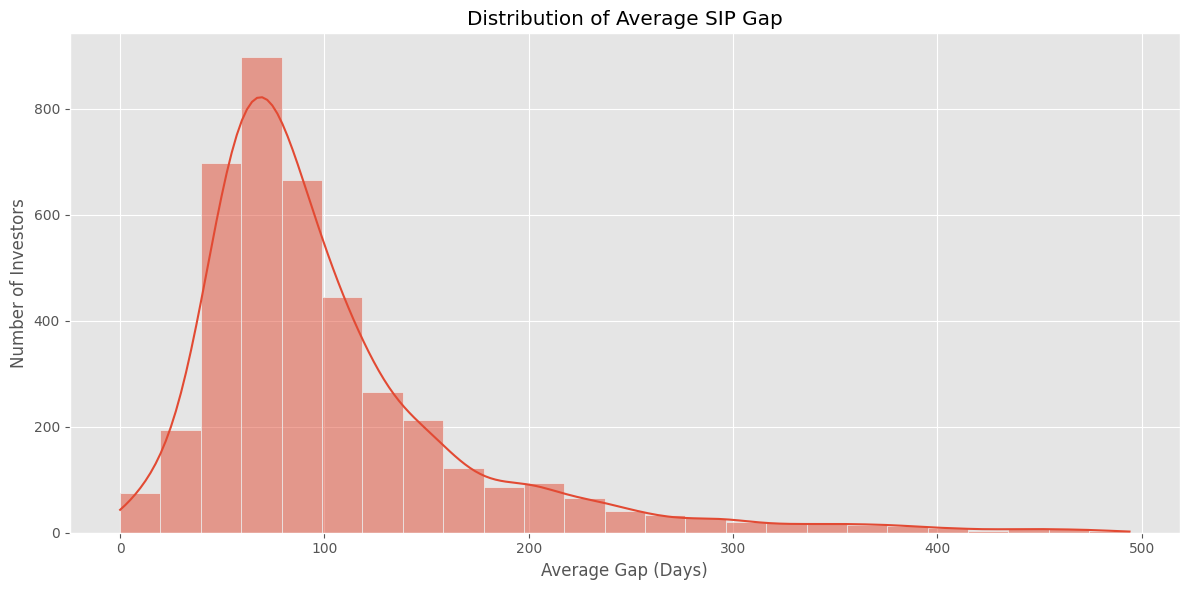

In [39]:
plt.figure(figsize=(12,6))

sns.histplot(
    continuity_report["average_gap_days"],
    bins=25,
    kde=True
)

plt.title("Distribution of Average SIP Gap")

plt.xlabel("Average Gap (Days)")

plt.ylabel("Number of Investors")

plt.tight_layout()

plt.show()

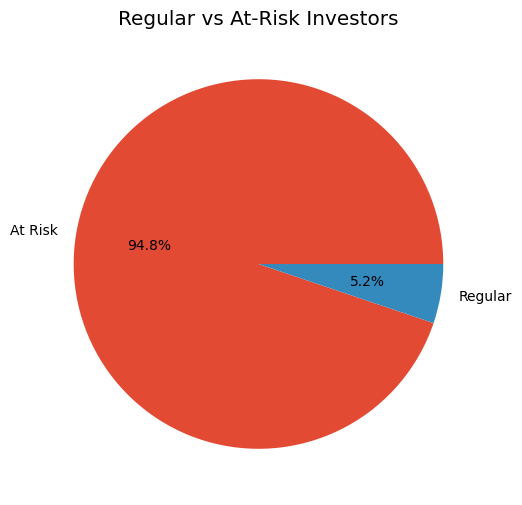

In [40]:
plt.figure(figsize=(6,6))

continuity_report["status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Regular vs At-Risk Investors")

plt.show()

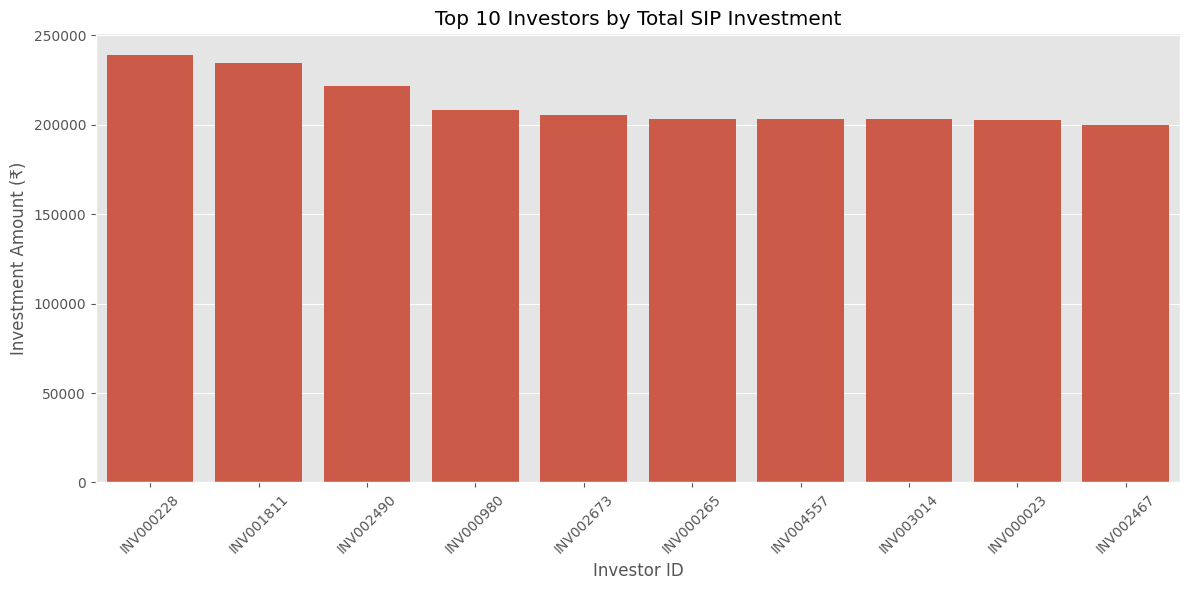

In [41]:
top10 = continuity_report.sort_values(
    "total_investment",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="investor_id",
    y="total_investment"
)

plt.title("Top 10 Investors by Total SIP Investment")

plt.xlabel("Investor ID")

plt.ylabel("Investment Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [42]:
portfolio = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

portfolio.head()


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [43]:
portfolio["weight_pct"] = portfolio["weight_pct"].astype(float)

portfolio["weight"] = portfolio["weight_pct"] / 100

In [44]:
sector_weights = (
    portfolio
    .groupby(["amfi_code", "sector"])["weight"]
    .sum()
    .reset_index()
)

sector_weights.head()

,amfi_code,sector,weight
0,100016,Automobile,0.1484
1,100016,Banking,0.0339
2,100016,Energy,0.0609
3,100016,FMCG,0.1168
4,100016,IT,0.2590


In [45]:
sector_hhi = (
    sector_weights
    .groupby("amfi_code")
    .apply(lambda x: (x["weight"] ** 2).sum())
    .reset_index(name="HHI")
)

sector_hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [46]:
sector_hhi = sector_hhi.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],

    on="amfi_code",

    how="left"

)

sector_hhi.head()

,amfi_code,HHI,scheme_name,fund_house,category
0,100016,0.180588,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
2,101206,0.180042,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
3,101207,0.222727,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
4,102885,0.180712,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity


In [47]:
equity_hhi = sector_hhi[
    sector_hhi["category"]
    .str.contains("Equity", case=False, na=False)
].copy()

equity_hhi.head()

,amfi_code,HHI,scheme_name,fund_house,category
0,100016,0.180588,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
2,101206,0.180042,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
3,101207,0.222727,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
4,102885,0.180712,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity


C:\Users\shrey\AppData\Local\Temp\ipykernel_16292\65845980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


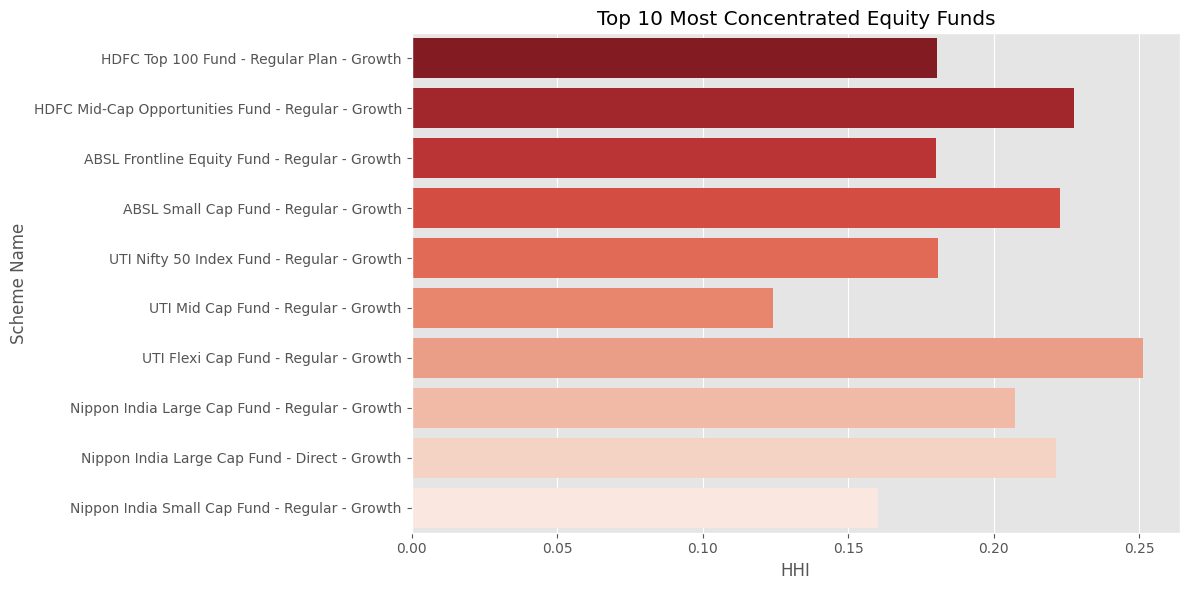

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=equity_hhi.head(10),
    x="HHI",
    y="scheme_name",
    palette="Reds_r"
)

plt.title("Top 10 Most Concentrated Equity Funds")

plt.xlabel("HHI")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_16292\3414875394.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


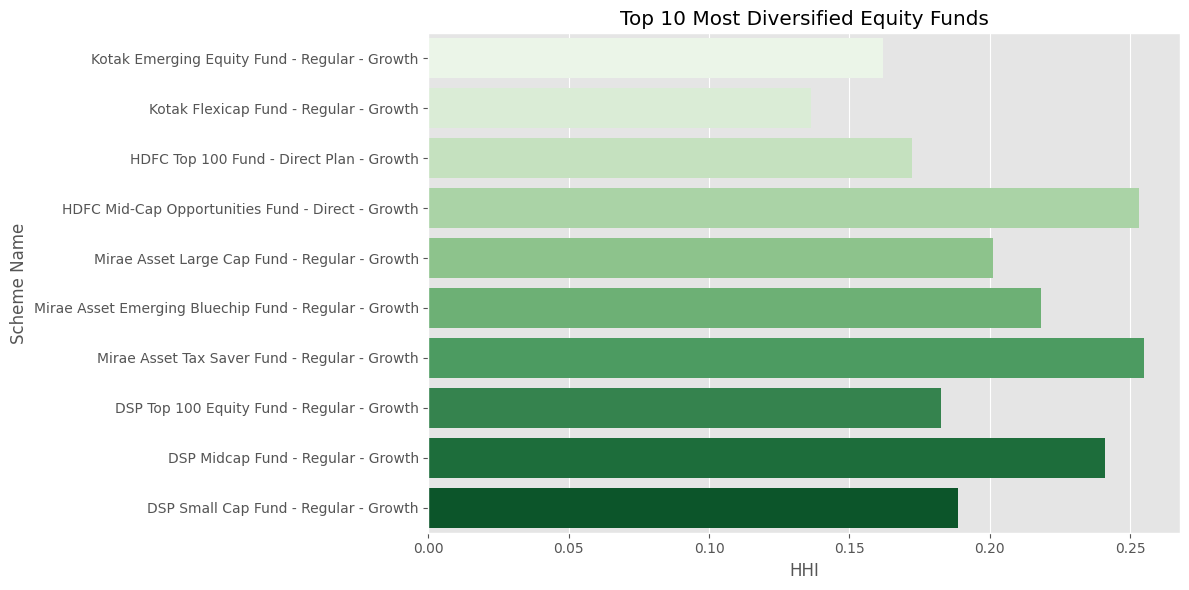

In [49]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=equity_hhi.tail(10),
    x="HHI",
    y="scheme_name",
    palette="Greens"
)

plt.title("Top 10 Most Diversified Equity Funds")

plt.xlabel("HHI")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

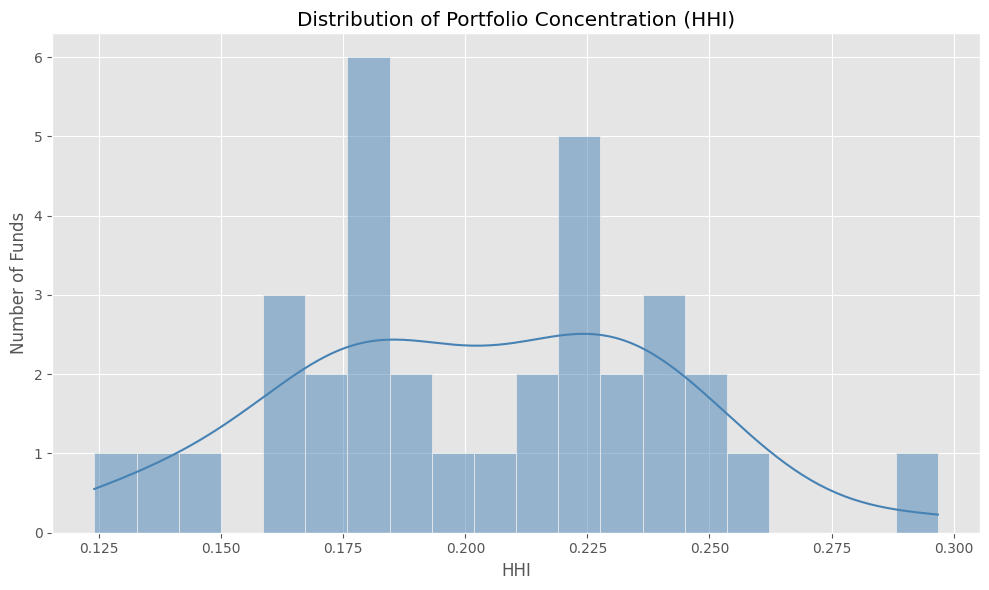

In [50]:
plt.figure(figsize=(10,6))

sns.histplot(
    equity_hhi["HHI"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Portfolio Concentration (HHI)")

plt.xlabel("HHI")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.show()

In [51]:
equity_hhi.describe()

,amfi_code,HHI
count,34.000000,34.000000
mean,121457.058824,0.202929
std,14988.778388,0.038622
min,100016.000000,0.124020
25%,118633.250000,0.180179
50%,119575.000000,0.204254
75%,120842.750000,0.230510
max,149324.000000,0.296769


In [52]:
equity_hhi[
    [
        "scheme_name",
        "fund_house",
        "HHI"
    ]
].head(15)

,scheme_name,fund_house,HHI
0,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,0.180588
1,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,0.227647
2,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,0.180042
3,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,0.222727
4,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,0.180712
5,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,0.124020
6,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,0.251383
7,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,0.207259
8,Nippon India Large Cap Fund - Direct - Growth,Nippon India MF,0.221200
9,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,0.160299


In [53]:
equity_hhi.to_csv(
    "../reports/sector_hhi_report.csv",
    index=False
)

print("Sector HHI report saved successfully!")

Sector HHI report saved successfully!


### Insight 1: Value at Risk (VaR) Analysis

Historical VaR and CVaR analysis showed that a small number of schemes experienced relatively larger downside risk than the majority of funds. Most schemes maintained moderate daily volatility, indicating stable long-term investment characteristics.

### Insight 2: Rolling Sharpe Ratio

The 90-day rolling Sharpe Ratio highlighted changes in risk-adjusted performance over time. Several funds consistently maintained higher Sharpe Ratios, suggesting stronger returns relative to the risk undertaken.

### Insight 3: Investor Cohort Analysis

Investor participation increased steadily across newer investment cohorts. Recent cohorts contributed a significant share of SIP investments, indicating growing investor confidence and increasing adoption of systematic investment plans.

### Insight 4: SIP Continuity Analysis

Most investors maintained regular SIP contributions with relatively short intervals between transactions. Investors showing long gaps between SIP payments were identified as potentially at risk of discontinuing their investment plans.

### Insight 5: Portfolio Concentration (HHI)

Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) revealed that some equity funds were highly concentrated in a limited number of sectors, while others maintained diversified sector allocations. Diversified portfolios generally provide lower concentration risk and improved resilience across market cycles.

# Conclusion

The Advanced Analytics module successfully evaluated mutual fund performance using multiple quantitative techniques, including risk measurement, portfolio concentration analysis, investor behavior analysis, and fund recommendation.

The analysis demonstrates how financial datasets can be transformed into actionable investment insights using Python, Pandas, NumPy, Matplotlib, and statistical methods.